In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_raw = pd.read_csv("ecommerce.csv")

In [ ]:
df_raw.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1654,542113,22891,TEA FOR ONE POLKADOT,3,1/25/2011 13:55,4.25,14341,United Kingdom
1101,575610,20717,STRAWBERRY SHOPPER BAG,10,11/10/2011 12:45,1.25,16628,United Kingdom
1149,572662,23295,SET OF 12 MINI LOAF BAKING CASES,8,10/25/2011 12:54,0.83,15443,United Kingdom
2763,552714,84946,ANTIQUE SILVER T-LIGHT GLASS,12,5/11/2011 9:28,1.25,17164,United Kingdom
3145,577807,23405,HOME SWEET HOME 2 DRAWER CABINET,4,11/22/2011 8:26,4.95,15699,United Kingdom


In [ ]:
df_raw[df_raw["Country"] == "Unspecified"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
114,557499,22627,MINT KITCHEN SCALES,2,6/20/2011 15:25,8.50,16320,Unspecified
439,561658,85213,MINI ZINC GARDEN DECORATIONS,12,7/28/2011 16:06,0.29,12743,Unspecified
1220,564051,22853,CAT BOWL VINTAGE CREAM,6,8/22/2011 13:32,3.25,14265,Unspecified
3853,561658,84879,ASSORTED COLOUR BIRD ORNAMENT,3,7/28/2011 16:06,1.69,12743,Unspecified


Country yang unspecified berjumlah 4 dari 4870 baris, karena jumlah nya terlalu sedikit, tidak perlu dihapus karena tidak akan terlalu mempengaruhi analisis. Akan dihapus jika analisis fokus untuk membandingkan suatu negara

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
df_raw["Description"].value_counts().sort_values(ascending=False).head(5)

,count
Description,
JUMBO BAG RED RETROSPOT,24
PARTY BUNTING,22
REGENCY CAKESTAND 3 TIER,21
WHITE HANGING HEART T-LIGHT HOLDER,19
60 TEATIME FAIRY CAKE CASES,18


In [ ]:
df_raw.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.000000,4870.000000,4870.000000,4870.000000
mean,560586.577413,12.945791,2.937057,15291.004312
std,13211.347819,38.145988,4.744515,1709.035002
min,536365.000000,1.000000,0.040000,12347.000000
25%,548861.000000,2.000000,1.250000,13975.000000
50%,561895.000000,5.000000,1.950000,15144.000000
75%,572126.000000,12.000000,3.750000,16793.250000
max,581585.000000,992.000000,145.000000,18283.000000


In [ ]:
df = df_raw.copy()

In [ ]:
#missingvalue
(df.isnull().sum()/len(df)*100).round(2)

,0
InvoiceNo,0.0
StockCode,0.0
Description,0.0
Quantity,0.0
InvoiceDate,0.0
UnitPrice,0.0
CustomerID,0.0
Country,0.0


In [ ]:
#cekduplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
#makesureduplicated
df[df.duplicated(keep=False)].sort_values("InvoiceNo")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
#datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["Hour"]=df["InvoiceDate"].dt.hour
df["Month"]=df["InvoiceDate"].dt.month_name()
df["Year"]=df["InvoiceDate"].dt.year
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [ ]:
#Hitung IQR untuk melihat outlier (kolom Unit Price)
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Batas bawah outlier: {batas_bawah:,.0f}")
print(f"Batas atas outlier: {batas_atas:,.0f}")

Q1: 1
Q3: 4
IQR: 2
Batas bawah outlier: -2
Batas atas outlier: 8


In [ ]:
# Hitung berapa banyak outlier
outliers_price = df[(df['UnitPrice'] < batas_bawah) | (df['UnitPrice'] > batas_atas)]
print(f"Jumlah outlier di kolom Unit Price: {len(outliers_price)}")
#outliers_price[['order_id', 'product_category', 'price']].sort_values('price', ascending=False).head(10)

Jumlah outlier di kolom Unit Price: 406


Berdasarkan metode IQR, ditemukan 406 data outlier pada kolom UnitPrice. Outlier tersebut menunjukkan adanya produk dengan harga yang jauh lebih tinggi dibanding mayoritas produk lainnya. Namun, karena dataset merupakan data retail transaksi, outlier kemungkinan merepresentasikan produk premium sehingga tidak langsung dihapus dari dataset.

In [ ]:
df["Country"].value_counts().head(5)

,count
Country,
United Kingdom,4346
Germany,121
EIRE,90
France,89
Switzerland,28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4870 non-null   int64         
 1   StockCode    4870 non-null   object        
 2   Description  4870 non-null   object        
 3   Quantity     4870 non-null   int64         
 4   InvoiceDate  4870 non-null   datetime64[ns]
 5   UnitPrice    4870 non-null   float64       
 6   CustomerID   4870 non-null   int64         
 7   Country      4870 non-null   object        
 8   Hour         4870 non-null   int32         
 9   Month        4870 non-null   object        
 10  Year         4870 non-null   int32         
 11  YearMonth    4870 non-null   period[M]     
dtypes: datetime64[ns](1), float64(1), int32(2), int64(3), object(4), period[M](1)
memory usage: 418.6+ KB


Setelah dilakukan cleaning dan feature engineer, bisa masuk ketahap analisa.

# Pertanyaan Analisa




## 1. Produk apa yang menghasilkan jumlah penjualan (Quantity) tertinggi?

In [ ]:
top_product = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

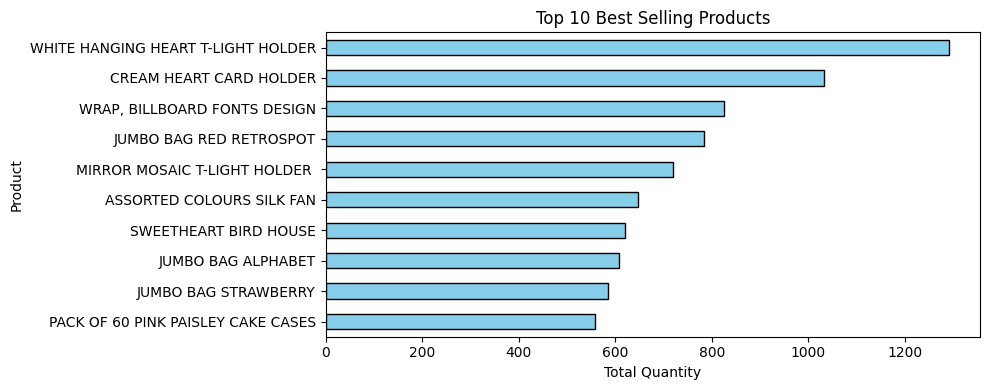

In [ ]:
plt.figure(figsize=(10, 4))
top_product.plot(
    kind="barh",
    color="skyblue",
    edgecolor="black"
)
plt.title("Top 10 Best Selling Products")
plt.xlabel("Total Quantity")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Produk “WHITE HANGING HEART T-LIGHT HOLDER” merupakan produk dengan jumlah penjualan (Quantity) tertinggi dibanding produk lainnya. Selain itu, beberapa produk dekorasi dan household mendominasi daftar top selling products.

## 2. Negara dengan penyumbang revenue terbesar?

In [ ]:
df["Revenue"]= df["Quantity"] * df["UnitPrice"]
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head()

display(country_revenue)

,Revenue
Country,
United Kingdom,93011.36
Netherlands,3622.33
Germany,3363.77
EIRE,3156.78
France,2320.55


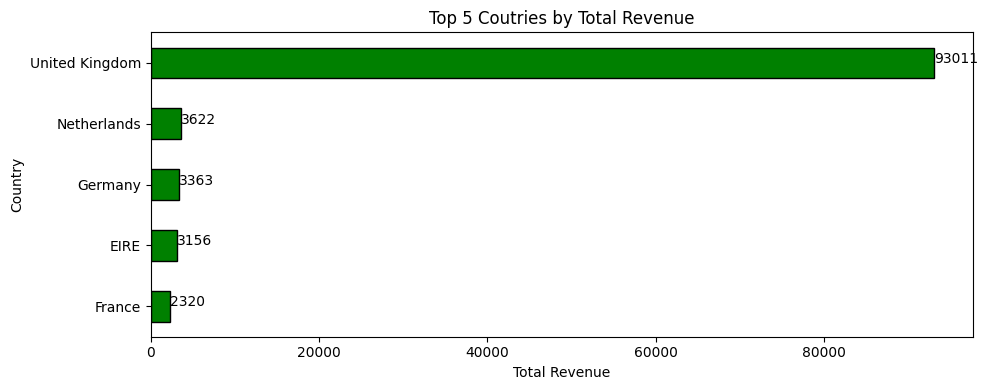

In [ ]:
plt.figure(figsize=(10, 4))
country_revenue.plot(
    kind="barh",
    color="green",
    edgecolor="black"
)
plt.title("Top 5 Coutries by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()
for index,value in enumerate(country_revenue.values):
  plt.text(value+ 1, index, int(value))

plt.tight_layout()
plt.show()

United Kingdom memiliki total revenue tertinggi dibanding negara lainnya, menunjukkan bahwa market utama perusahaan sangat terkonsentrasi pada wilayah tersebut. Perbedaan revenue yang cukup besar antar negara juga mengindikasikan adanya ketimpangan kontribusi market secara global.

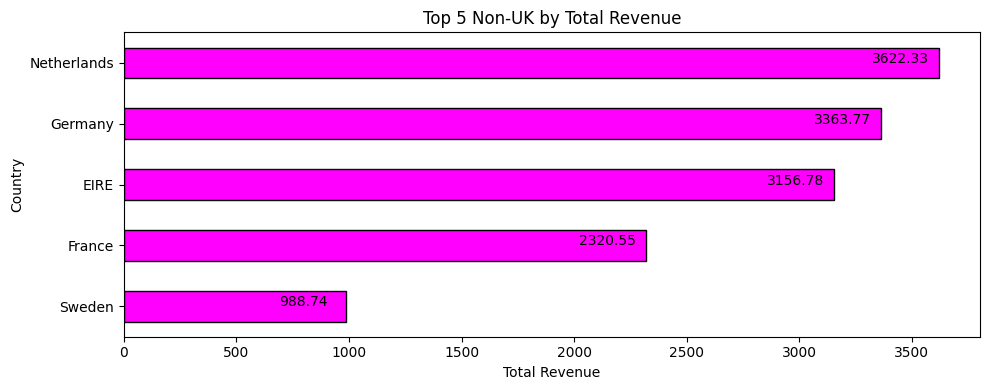

In [ ]:
non_uk = df[df["Country"] != "United Kingdom"]
top_non_uk = non_uk.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head()

plt.figure(figsize=(10, 4))
top_non_uk.plot(
    kind="barh",
    color="magenta",
    edgecolor="black"
)
plt.title("Top 5 Non-UK by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()
for index,value in enumerate(top_non_uk.values):
  plt.text(value-300, index, str(value))

plt.tight_layout()
plt.show()

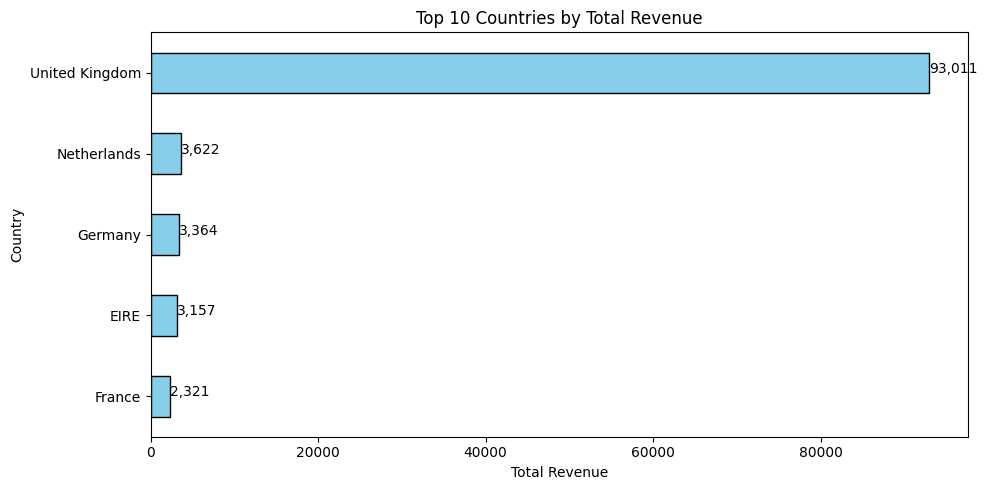

In [ ]:
#Analisis menggunakan Pivot table
pivot_country = pd.pivot_table(
    df,
    index="Country",
    values="Revenue",
    aggfunc="sum"
).sort_values(by="Revenue", ascending=False).head(5)

plt.figure(figsize=(10,5))

pivot_country["Revenue"].plot(
    kind="barh",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()

for index, value in enumerate(pivot_country["Revenue"]):
    plt.text(value, index, f"{value:,.0f}")

plt.tight_layout()
plt.show()

 Analisis menunjukkan bahwa United Kingdom merupakan market utama perusahaan dengan total revenue sekitar 93.011, jauh melampaui negara lainnya. Revenue United Kingdom sekitar 26 kali lebih besar dibandingkan Netherlands sebagai negara non-UK dengan revenue tertinggi. Maka dari itu dibutuhkan grafik baru khusus untuk Non-UK. Secara market Non-UK, Netherlands menjadi negara tertinggi dibandingkan negara lain. Meskipun Netherlands memiliki revenue tertinggi, belum tentu negara tersebut memiliki jumlah transaksi atau quantity pembelian terbesar. Oleh karena itu, analisis lanjutan mengenai jumlah transaksi dan produk yang paling banyak dibeli pada masing-masing negara diperlukan untuk memahami perilaku pembelian customer secara lebih mendalam.

## 3. Tren penjualan setiap bulan

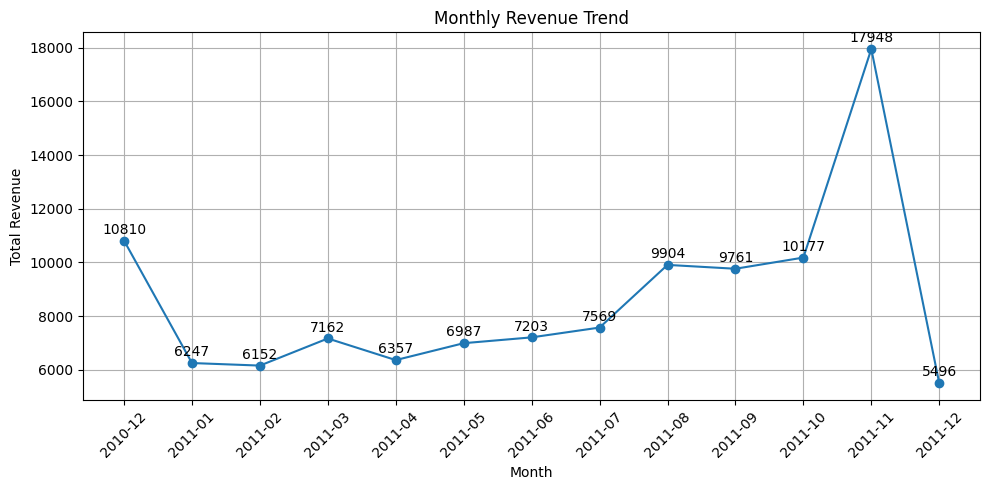

In [ ]:
monthly_sales = df.groupby("YearMonth")["Revenue"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(True)

for i, value in enumerate(monthly_sales.values):
    plt.text(
        i,
        value + 250,
        int(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
df[df["YearMonth"] == "2011-10"]["Revenue"].sum()

np.float64(10177.380000000001)

Perusahaan menunjukkan pertumbuhan revenue yang konsisten sepanjang tahun 2011 dan mencapai puncaknya pada November 2011. Oleh karena itu, bulan-bulan menjelang akhir tahun dapat menjadi fokus utama untuk strategi promosi dan peningkatan penjualan karena memiliki potensi revenue yang lebih tinggi dibandingkan periode lainnya.

## 4. Customer dengan transaksi tertinggi

In [ ]:
top_customer = df.groupby ("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(5)


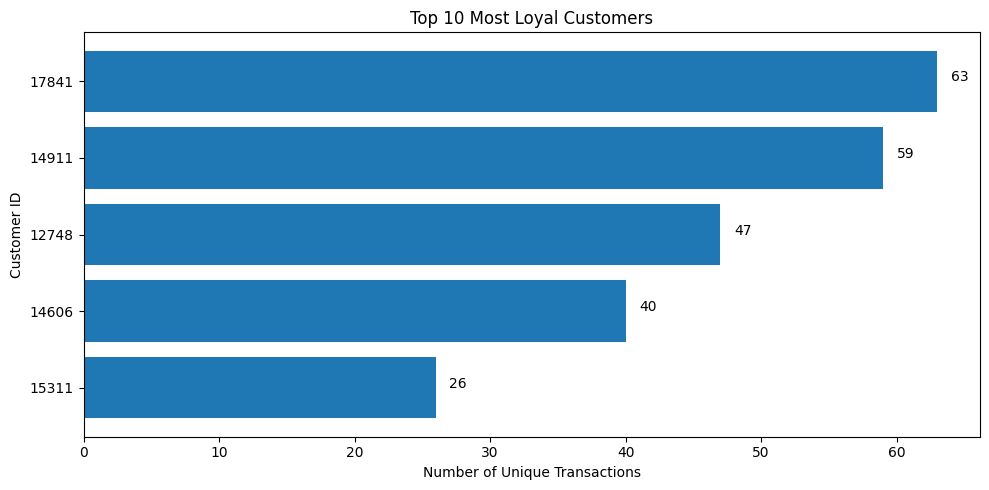

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(top_customer.index.astype(str),
         top_customer.values)

plt.title("Top 10 Most Loyal Customers")
plt.xlabel("Number of Unique Transactions")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

for index, value in enumerate(top_customer.values):
    plt.text(value + 1, index, str(value))

plt.tight_layout()
plt.show()

Perusahaan memiliki beberapa pelanggan dengan tingkat loyalitas yang sangat tinggi yang berkontribusi besar terhadap aktivitas transaksi. Customer dengan frekuensi transaksi tertinggi dapat dikategorikan sebagai "Loyal Customer" dan berpotensi menjadi target utama dalam program retensi pelanggan, loyalty program, maupun penawaran eksklusif untuk mempertahankan hubungan jangka panjang.

## 5. Apakah harga produk dapat mempengaruhi penjualan?

In [ ]:
df[["UnitPrice","Quantity"]].corr()

,UnitPrice,Quantity
UnitPrice,1.000000,-0.083283
Quantity,-0.083283,1.000000


<Axes: >

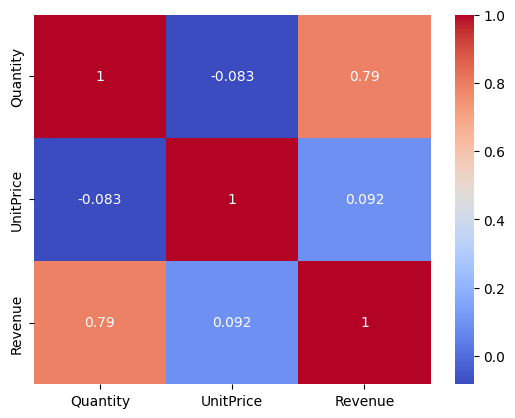

In [ ]:
sns.heatmap(df[["Quantity","UnitPrice","Revenue"]].corr(),
            annot=True,
            cmap="coolwarm")

Revenue perusahaan lebih dipengaruhi oleh kuantitas produk yang terjual dibandingkan harga produk. Dengan korelasi sebesar 0,79, peningkatan volume penjualan berpotensi memberikan dampak yang lebih besar terhadap pertumbuhan revenue dibandingkan hanya menaikkan harga produk. Oleh karena itu, strategi bisnis seperti promosi penjualan, bundling produk, atau program loyalitas pelanggan dapat menjadi cara yang efektif untuk meningkatkan revenue melalui peningkatan jumlah transaksi dan produk yang terjual.

## 6. Peak Hours?

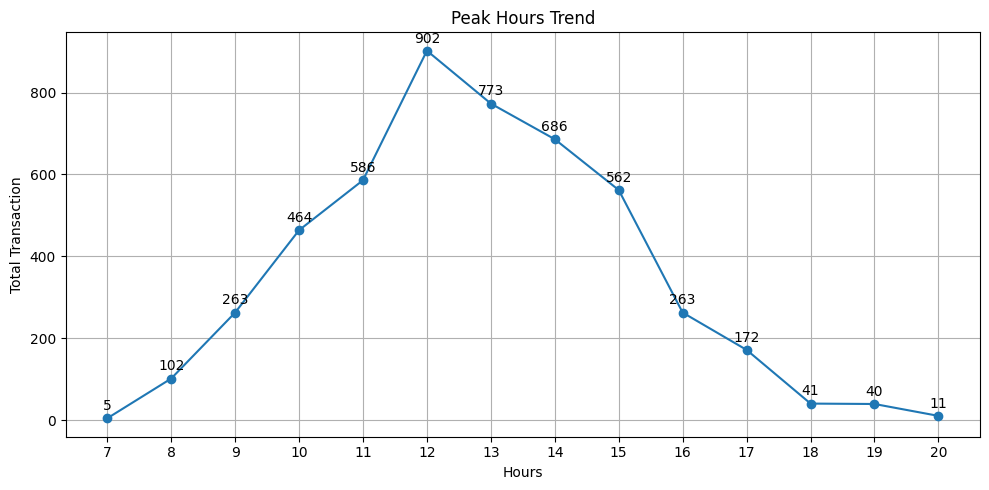

In [ ]:
peak_hours = df.groupby("Hour")["InvoiceNo"].count()

plt.figure(figsize=(10,5))
plt.plot(peak_hours.index.astype(str), peak_hours.values, marker="o")

plt.title("Peak Hours Trend")
plt.xlabel("Hours")
plt.ylabel("Total Transaction")

#plt.xticks(rotation=45)

plt.grid(True)

for i, value in enumerate(peak_hours.values):
    plt.text(
        i,
        (value+20),
        int(value),
        ha="center"
        )

plt.tight_layout()
plt.show()


Aktivitas transaksi paling tinggi terjadi pada rentang 11.00-14.00, dengan puncak transaksi pada pukul 12.00. Oleh karena itu, perusahaan dapat memanfaatkan periode tersebut untuk menjalankan promosi, flash sale, atau meningkatkan kesiapan operasional dan layanan pelanggan. Diluar jam tersebut, bisa digunakan untuk persiapan stok di hari berikutnya

TERIMA KASIH

Day 20 - Assignment Advanced Exploratory Data Analysis

M AQILA MUSYAFFA - DABI22

In [ ]:
df.to_csv("online_retail_clean.csv", index=False)

In [ ]:
from google.colab import files
files.download("online_retail_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DATA VISUALIZATION USING DATA STUDIO
https://datastudio.google.com/reporting/7c7cf6fd-9959-4c3a-a75e-cca45ca482c7
